### [Unmasking Anomalies in Time Series](https://medium.com/code-applied/beyond-forecasts-unmasking-anomalies-in-time-series-data-with-facebook-prophet-9dd485c1bf00)

> Leveraging Prophet for Anomaly Detection

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

,ds,y
0,2024-01-01,100
1,2024-01-02,105
2,2024-01-03,110
3,2024-01-04,115
4,2024-01-05,120
5,2024-01-06,10
6,2024-01-07,130
7,2024-01-08,135
8,2024-01-09,140
9,2024-01-10,145


<Axes: xlabel='ds'>

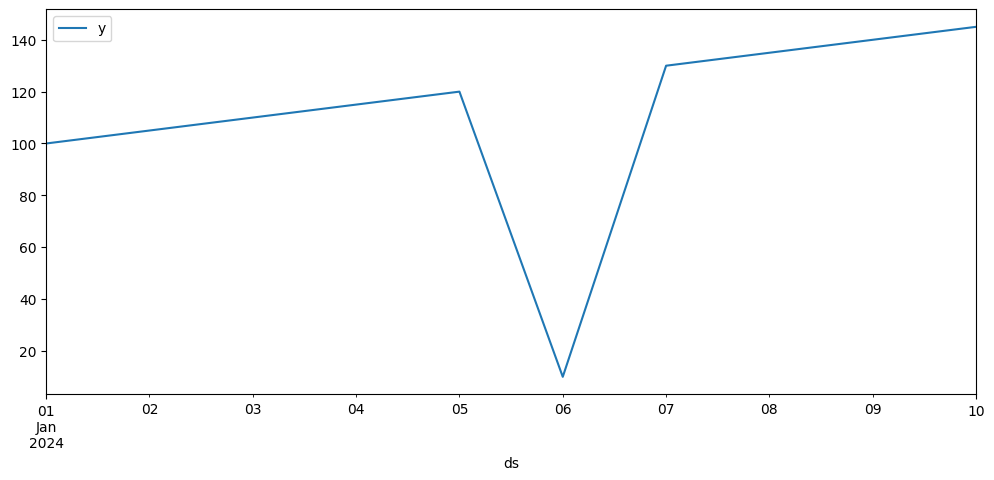

In [2]:
# A sample dataset to simulate a time series
data = {
    'ds': pd.date_range(start='2024-01-01', end='2024-01-10'),
    'y': [100, 105, 110, 115, 120, 10, 130, 135, 140, 145] # Note the anomaly at index 5
}
df = pd.DataFrame(data)
display(df)

# View series
df.plot(x='ds', y='y', figsize=(12,5))

#### 1. Model Training

In [3]:
# Initialize and fit the Prophet model
m = Prophet(
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)
m.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.


#### 2. Making Forecasts on Historical Data

In [4]:
# Create a future dataframe that covers our existing data
future = m.make_future_dataframe(periods=0)

# Generate predictions
forecast = m.predict(future)

In [5]:
display(future)

,ds
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05
5,2024-01-06
6,2024-01-07
7,2024-01-08
8,2024-01-09
9,2024-01-10


In [6]:
display(forecast)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,91.810887,47.015041,135.494675,91.810887,91.810887,0.0,0.0,0.0,0.0,0.0,0.0,91.810887
1,2024-01-02,96.115169,54.344651,139.885664,96.115169,96.115169,0.0,0.0,0.0,0.0,0.0,0.0,96.115169
2,2024-01-03,100.419450,53.093567,141.527886,100.419450,100.419450,0.0,0.0,0.0,0.0,0.0,0.0,100.419450
3,2024-01-04,104.723732,59.388943,147.560208,104.723732,104.723732,0.0,0.0,0.0,0.0,0.0,0.0,104.723732
4,2024-01-05,109.028014,62.756295,148.107641,109.028014,109.028014,0.0,0.0,0.0,0.0,0.0,0.0,109.028014
5,2024-01-06,113.332295,65.933900,156.627130,113.332295,113.332295,0.0,0.0,0.0,0.0,0.0,0.0,113.332295
6,2024-01-07,117.636577,72.443527,162.880898,117.636577,117.636577,0.0,0.0,0.0,0.0,0.0,0.0,117.636577
7,2024-01-08,121.940858,76.706762,165.975071,121.940858,121.940858,0.0,0.0,0.0,0.0,0.0,0.0,121.940858
8,2024-01-09,126.245140,83.853028,168.867810,126.245140,126.245140,0.0,0.0,0.0,0.0,0.0,0.0,126.245140
9,2024-01-10,130.549422,86.291358,176.672178,130.549422,130.549422,0.0,0.0,0.0,0.0,0.0,0.0,130.549422


#### 3. Quantifying and Visualizing Anomalies

In [7]:
# Merge the actual data and the forecast
df_combined = pd.merge(df, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# Identify anomalies: where the actual value 'y' is outside the prediction interval
df_combined['is_anomaly'] = (df_combined['y'] < df_combined['yhat_lower']) | (df_combined['y'] > df_combined['yhat_upper'])

# Print the anomalies found
print("Detected Anomalies:")
display(df_combined[df_combined['is_anomaly']])

Detected Anomalies:


,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly
5,2024-01-06,10,113.332295,65.9339,156.62713,True


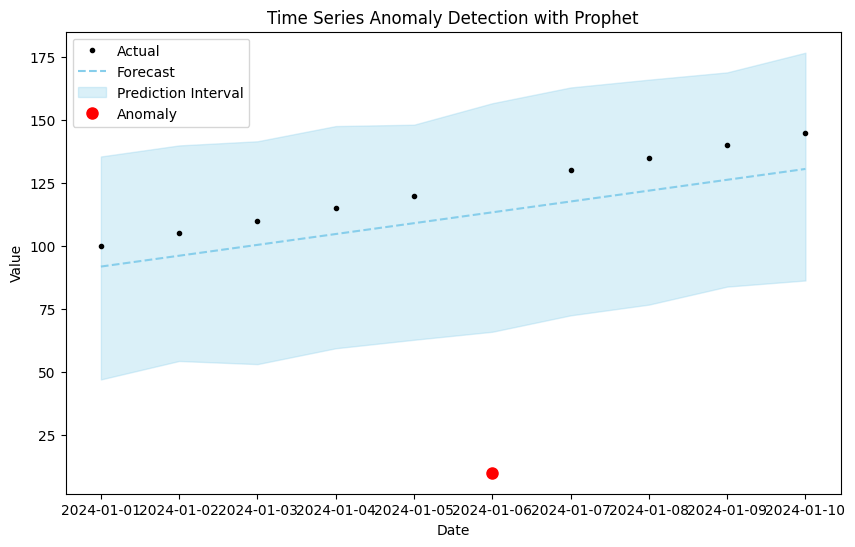

In [8]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_combined['ds'], df_combined['y'], 'k.', label='Actual')
ax.plot(df_combined['ds'], df_combined['yhat'], color='skyblue', linestyle='--', label='Forecast')
ax.fill_between(df_combined['ds'], df_combined['yhat_lower'], df_combined['yhat_upper'], color='skyblue', alpha=0.3, label='Prediction Interval')

# Highlight the anomalies
anomalies = df_combined[df_combined['is_anomaly']]
ax.plot(anomalies['ds'], anomalies['y'], 'ro', markersize=8, label='Anomaly')
ax.set_title("Time Series Anomaly Detection with Prophet")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
plt.show()